# 01 - Data Processing

## Goal
Turn raw minute-level Bitcoin data into a clean, **leakage-free**, model-ready
dataset, and rigorously establish the **statistical properties** (stationarity)
that justify the modelling choices made later.

We frame the project as a **binary classification problem**: *given information at
hour `t`, will the log-return of hour `t+1` be positive?* We also keep the
stationary **return series** so the time-series models (ARIMA / GARCH / Prophet)
can be fitted in notebook 03.

## Pipeline
`01_data_processing` -> 02_eda -> 03_modelling -> 04_analysis -> 05_final_report

## Steps
1. Download raw data.
2. Window + hourly resample. 
3. Validate.
4. **Stationarity investigation** (returns -> detrend -> outliers -> differencing,ADF/KPSS each stage). 
5. Feature engineering. 
6. Target (no leakage).
7. Chronological split. 
8. Persist.



## 0. Setup

In [1]:
from pathlib import Path                       # object-oriented filesystem paths

PROJECT_ROOT   = Path.cwd().parent             # notebooks -> repository root
DATA_RAW       = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
MODELS_DIR     = PROJECT_ROOT / "models"
REPORTS_DIR    = PROJECT_ROOT / "reports"
MLRUNS_DIR     = PROJECT_ROOT / "mlruns"

for _d in (DATA_RAW, DATA_PROCESSED, MODELS_DIR, REPORTS_DIR, MLRUNS_DIR):
    _d.mkdir(parents=True, exist_ok=True)      # create folders if missing
print("Project root:", PROJECT_ROOT)

Project root: c:\Users\Użytkownik\Desktop\studia\magisterka\Machine learning\Project\MLDA - checking


In [2]:
import numpy as np
import random

RANDOM_SEED = 47                    # global seed
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
print(f"Random seed set to {RANDOM_SEED}")

Random seed set to 47


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)

## 1. Download the raw data
Dataset: **mczielinski/bitcoin-historical-data** (minute-level BTC/USD), pulled
programmatically so the large raw file never enters version control.


In [4]:
import kagglehub
import os

dataset_path = kagglehub.dataset_download("mczielinski/bitcoin-historical-data")
raw_csv_path = os.path.join(dataset_path, "btcusd_1-min_data.csv")
df_raw = pd.read_csv(raw_csv_path)
print(f"Raw shape: {df_raw.shape}\n")

Raw shape: (7608981, 6)



In [5]:
df_raw.head()

,Timestamp,Open,High,Low,Close,Volume
0,1325376060,4.58,4.58,4.58,4.58,0.0
1,1325376120,4.58,4.58,4.58,4.58,0.0
2,1325376180,4.58,4.58,4.58,4.58,0.0
3,1325376240,4.58,4.58,4.58,4.58,0.0
4,1325376300,4.58,4.58,4.58,4.58,0.0


Checking types of raw data

In [6]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7608981 entries, 0 to 7608980
Data columns (total 6 columns):
 #   Column     Dtype  
---  ------     -----  
 0   Timestamp  int64  
 1   Open       float64
 2   High       float64
 3   Low        float64
 4   Close      float64
 5   Volume     float64
dtypes: float64(5), int64(1)
memory usage: 348.3 MB


Checking numbers of nulls in raw data

In [7]:
df_raw.isna().any()

Timestamp    False
Open         False
High         False
Low          False
Close        False
Volume       False
dtype: bool

## 2. Time window and hourly resampling

In [8]:
df_raw["Datetime"] = pd.to_datetime(df_raw["Timestamp"], unit="s")   # UNIX -> datetime

START_DATE, END_DATE = "2025-01-01", "2026-01-01"
mask = (df_raw["Datetime"] >= START_DATE) & (df_raw["Datetime"] < END_DATE)
df_window = df_raw.loc[mask].set_index("Datetime").sort_index()

close_hourly = df_window["Close"].resample("1h").last().dropna()   # last close per hour
print(f"Window {START_DATE} -> {END_DATE} | hourly obs: {len(close_hourly):,}")
close_hourly.head()

Window 2025-01-01 -> 2026-01-01 | hourly obs: 8,760


Datetime
2025-01-01 00:00:00    94211.0
2025-01-01 01:00:00    93421.0
2025-01-01 02:00:00    93858.0
2025-01-01 03:00:00    93629.0
2025-01-01 04:00:00    93355.0
Freq: h, Name: Close, dtype: float64

## 3. Data validation

In [9]:
assert close_hourly.notna().all(), "Hourly series still has NaNs!"
assert (close_hourly > 0).all(),   "Found non-positive prices!"
print(f"Duplicated timestamps: {close_hourly.index.duplicated().sum()}")
print(f"Date range : {close_hourly.index.min()} -> {close_hourly.index.max()}")
print(f"Price range: {close_hourly.min():,.2f} -> {close_hourly.max():,.2f} USD")
print(f"Negative prices (mistakes): {sum(df_raw['Close'] < 0)}")

Duplicated timestamps: 0
Date range : 2025-01-01 00:00:00 -> 2025-12-31 23:00:00
Price range: 74,724.00 -> 126,111.00 USD
Negative prices (mistakes): 0


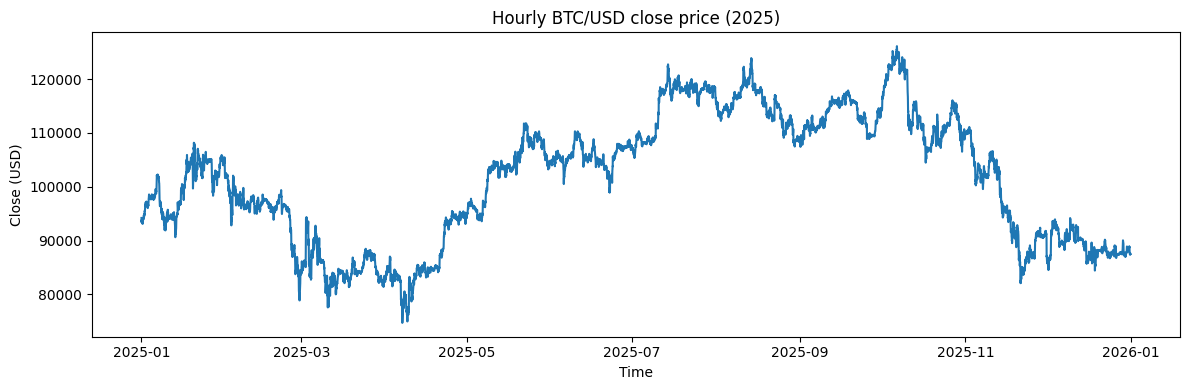

In [10]:
plt.figure(figsize=(12, 4))
plt.plot(close_hourly.index, close_hourly.values)
plt.title("Hourly BTC/USD close price (2025)")
plt.xlabel("Time"); plt.ylabel("Close (USD)"); plt.tight_layout(); plt.show()

## 4. Stationarity investigation
Time-series models need a **stationary** input. We test the series step by step -
raw log-returns, then detrending, outlier removal, and second differencing - with
**ADF** and **KPSS** (opposite nulls, so agreement is strong evidence). The
conclusion decides which series and ARIMA `d` to use in notebook 03.


In [11]:
from statsmodels.tsa.stattools import adfuller, kpss

def stationarity_report(series, name="series"):
    """Run ADF and KPSS stationarity tests and print plain-English verdicts.

    The two tests use opposite null hypotheses, so agreement between them is
    strong evidence about stationarity.

    Parameters
    ----------
    series : pandas.Series
        Time series to test (NaNs are dropped internally).
    name : str, optional
        Label used in the printed header.

    Returns
    -------
    None
        Results are printed, not returned.
    """
    s = series.dropna()
    # ADF: H0 = unit root (NON-stationary). Small p -> stationary.
    adf_stat, adf_p, *_ = adfuller(s)
    # KPSS: H0 = stationary (opposite framing). Small p -> NON-stationary.
    kpss_stat, kpss_p, *_ = kpss(s, regression="c", nlags="auto")
    print(f"=== {name} ===")
    print(f"  ADF : stat={adf_stat:8.4f}  p={adf_p:.4f} -> "
          f"{'STATIONARY' if adf_p < 0.05 else 'non-stationary'}")
    print(f"  KPSS: stat={kpss_stat:8.4f}  p={kpss_p:.4f} -> "
          f"{'non-stationary' if kpss_p < 0.05 else 'STATIONARY'}\n")

In [12]:
log_return = np.log(close_hourly / close_hourly.shift(1)).dropna()
stationarity_report(log_return, "hourly log-returns")

=== hourly log-returns ===
  ADF : stat=-22.9772  p=0.0000 -> STATIONARY
  KPSS: stat=  0.1360  p=0.1000 -> STATIONARY



C:\Users\Użytkownik\AppData\Local\Temp\ipykernel_19276\2740261843.py:25: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(s, regression="c", nlags="auto")


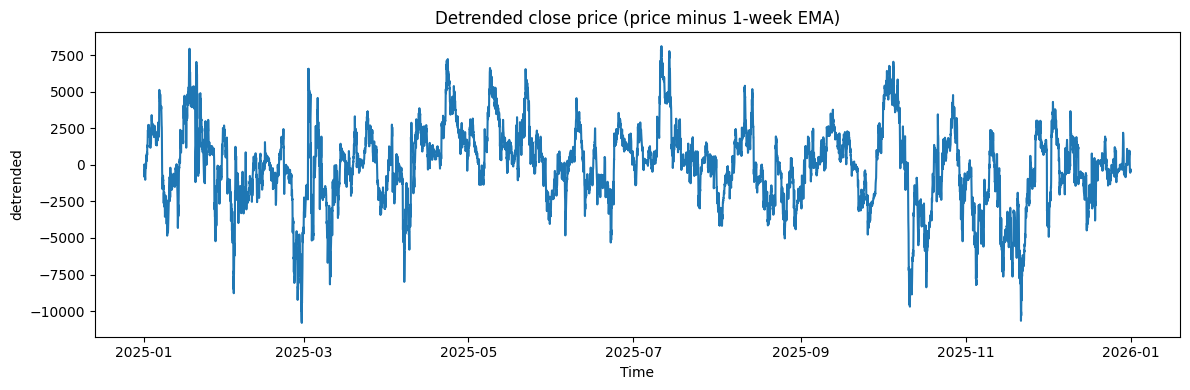

In [13]:
span = 7 * 24                                              # 1-week EMA span
trend = close_hourly.ewm(span=span, adjust=False).mean()   # y_t=a*x_t+(1-a)*y_{t-1}
detrended = close_hourly - trend
plt.figure(figsize=(12, 4)); plt.plot(detrended.index, detrended.values)
plt.title("Detrended close price (price minus 1-week EMA)")
plt.xlabel("Time"); plt.ylabel("detrended"); plt.tight_layout(); plt.show()

In [14]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(n_estimators=100, contamination=0.01, random_state=RANDOM_SEED)
flags = iso.fit_predict(log_return.values.reshape(-1, 1))   # +1 inlier, -1 outlier
log_return_clean = log_return[flags == 1]
print(f"Removed {int((flags == -1).sum())} outliers "
      f"({(flags == -1).mean()*100:.2f}% of the series).")

Removed 87 outliers (0.99% of the series).


In [15]:
second_return = log_return_clean.diff().dropna()
stationarity_report(log_return_clean, "log-returns (outliers removed)")
stationarity_report(second_return,    "second-differenced returns")

C:\Users\Użytkownik\AppData\Local\Temp\ipykernel_19276\2740261843.py:25: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(s, regression="c", nlags="auto")


=== log-returns (outliers removed) ===
  ADF : stat=-18.0463  p=0.0000 -> STATIONARY
  KPSS: stat=  0.1938  p=0.1000 -> STATIONARY

=== second-differenced returns ===
  ADF : stat=-27.5766  p=0.0000 -> STATIONARY
  KPSS: stat=  0.0508  p=0.1000 -> STATIONARY



C:\Users\Użytkownik\AppData\Local\Temp\ipykernel_19276\2740261843.py:25: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(s, regression="c", nlags="auto")


**Decision:** the hourly log-returns are already stationary by ADF, so the time-series models use the **log-return series with `d = 0`**. The detrend/outlier/differencing steps are kept as documented justification.


## 5. Feature engineering
All features use **past-only** information.

In [16]:
data = pd.DataFrame({"Close": close_hourly})
data["log_return"] = np.log(data["Close"] / data["Close"].shift(1))   # stationary signal

for lag in range(1, 11):                                   # short-horizon autocorr
    data[f"log_return_lag_{lag}"] = data["log_return"].shift(lag)

for w in [3, 7, 14]:                                       # local trend & volatility
    data[f"roll_mean_{w}"]     = data["log_return"].rolling(w).mean()
    data[f"roll_std_{w}"]      = data["log_return"].rolling(w).std()
    data[f"abs_roll_mean_{w}"] = data["log_return"].abs().rolling(w).mean()

for w in [3, 7, 14]:                                       # momentum / drift
    data[f"momentum_{w}"] = data["Close"] / data["Close"].shift(w) - 1

data["abs_log_return"] = data["log_return"].abs()          # volatility proxies
data["sq_log_return"]  = data["log_return"] ** 2
print(f"Feature frame shape (pre-target/dropna): {data.shape}")

Feature frame shape (pre-target/dropna): (8760, 26)


## 6. Target definition (no leakage)

In [17]:
data["fwd_return"] = data["log_return"].shift(-1)          # next-hour return (for backtest)
data["target"] = (data["fwd_return"] > 0).astype(int)      # 1 if next hour up

data.loc[data["fwd_return"].isna(), "target"] = np.nan
data_clean = data.dropna().copy()
data_clean["target"] = data_clean["target"].astype(int)
print(f"Rows after cleaning: {len(data_clean):,}")
print(data_clean["target"].value_counts(normalize=True).round(4))

Rows after cleaning: 8,745
target
1    0.5035
0    0.4965
Name: proportion, dtype: float64


## 7. Chronological train / validation / test split (70/15/15)

In [18]:
FEATURE_COLS = [col for col in data_clean.columns
                if col not in ("Close", "target", "fwd_return")]
n = len(data_clean); i_train, i_val = int(n*0.70), int(n*0.85)
df_train = data_clean.iloc[:i_train].copy()
df_val   = data_clean.iloc[i_train:i_val].copy()
df_test  = data_clean.iloc[i_val:].copy()
print(f"Train {len(df_train):,} | Val {len(df_val):,} | Test {len(df_test):,}")
print(f"Features: {len(FEATURE_COLS)}")

Train 6,121 | Val 1,312 | Test 1,312
Features: 25


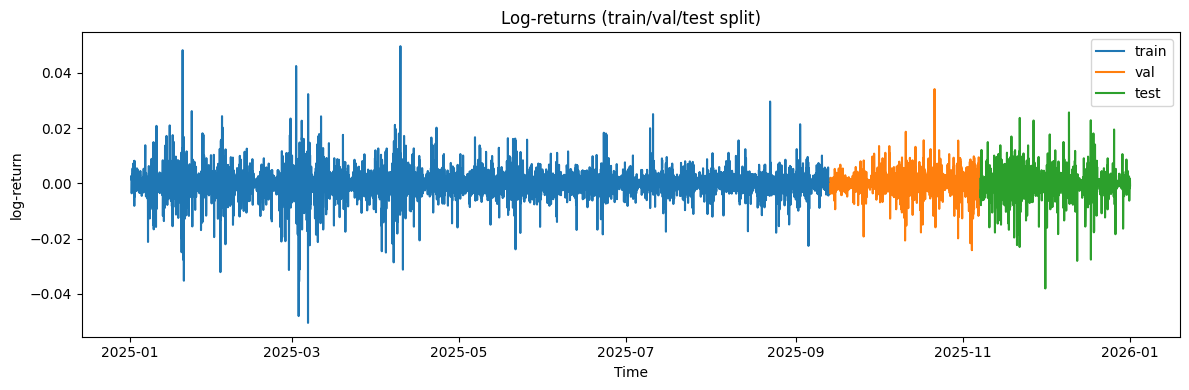

In [19]:
plt.figure(figsize=(12, 4))
plt.plot(df_train.index, df_train["log_return"], label="train")
plt.plot(df_val.index,   df_val["log_return"],   label="val")
plt.plot(df_test.index,  df_test["log_return"],  label="test")
plt.title("Log-returns (train/val/test split)")
plt.xlabel("Time"); plt.ylabel("log-return")
plt.legend()
plt.tight_layout()
plt.show()

## 8. Persist the processed data

In [20]:
import json
df_train.to_csv(DATA_PROCESSED / "train.csv")
df_val.to_csv(  DATA_PROCESSED / "val.csv")
df_test.to_csv( DATA_PROCESSED / "test.csv")
meta = {"feature_cols": FEATURE_COLS, "target": "target", "fwd_return": "fwd_return",
        "start_date": START_DATE, "end_date": END_DATE, "frequency": "1h",
        "random_seed": RANDOM_SEED}
with open(DATA_PROCESSED / "metadata.json", "w") as f:
    json.dump(meta, f, indent=2)
print("Saved:", *[p.name for p in sorted(DATA_PROCESSED.glob("*"))])

Saved: metadata.json test.csv train.csv val.csv


## 9. Summary
Downloaded & validated hourly 2025 data; investigated stationarity and chose to
model log-returns (`d=0`); engineered leakage-free features; defined the direction
target; split chronologically; persisted everything.

-> **Next:** `02_eda.ipynb`.
